# Data Validation
- Purpose to assess data structure, anomalies, NULLs, formatting, and distributions.
- Data covers SBA 7(a) loans from the FOIA dataset, FY2010-FY2019, snapshot dated 2025-12-31. 545,751 rows.
- Findings will help determine SQL views to configure during the cleaning phase.

## Sections
- Notebook contains 5 sections:
    1. Structural Overview
    2. Categorical Data Summary Stats
    3. Numeric Data Summary Stats
    4. Date Logic and Ranges
    5. Cleaning Decisions Summary


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))

load_dotenv()
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')
name = os.getenv('DB_NAME')
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')

engine = create_engine(f"postgresql+psycopg2://{user}:{password}@{host}:{port}/{name}")

df = pd.read_sql_table('loans_raw', engine, schema='sba')

print(df.shape)

(545751, 43)


## Structural Overview

In [29]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 545751 entries, 0 to 545750
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype        
---  ------                      --------------   -----        
 0   loan_id                     545751 non-null  int64        
 1   program                     545751 non-null  str          
 2   location_id                 545246 non-null  str          
 3   borr_name                   545721 non-null  str          
 4   borr_street                 545751 non-null  str          
 5   borr_city                   545751 non-null  str          
 6   borr_state                  545751 non-null  str          
 7   borr_zip                    545751 non-null  str          
 8   bank_name                   545751 non-null  str          
 9   bank_fdic_number            506748 non-null  str          
 10  bank_ncua_number            17265 non-null   str          
 11  bank_street                 545246 non-null  str          
 12 

,loan_id,program,location_id,borr_name,borr_street,borr_city,borr_state,borr_zip,bank_name,bank_fdic_number,...,business_type,business_age,loan_status,paid_in_full_date,charge_off_date,gross_charge_off_amount,revolver_status,jobs_supported,collateral_ind,sold_secondary_mrkt
0,1,7A,59698,Sunil Kumar Kumria dba HUGHSON SHELL,2468 3rd Street,Hughson,CA,95326,Columbia Bank,17266,...,INDIVIDUAL,NaN,PIF,2017-11-30,NaT,0.00,False,5.00,Y,Y
1,2,7A,48270,Ecousable Inc.,500 S. Sepulveda Blvd Ste 106,MANHATTAN BEACH,CA,90266,"JPMorgan Chase Bank, National Association",628,...,CORPORATION,NaN,PIF,2011-07-31,NaT,0.00,False,16.00,Y,NaN
2,3,7A,106670,Juan M. Valadez DBA J.'s Valadez Masonry,105 Nikki Lane,Comfort,TX,78013,United Texas Credit Union,NaN,...,INDIVIDUAL,NaN,PIF,2015-04-30,NaT,0.00,True,15.00,N,NaN
3,4,7A,44449,Moon's Services Inc.,10416 Cibolo Drive.,Edinburg,TX,78542,"PNC Bank, National Association",6384,...,CORPORATION,NaN,PIF,2017-02-28,NaT,0.00,True,2.00,N,NaN
4,5,7A,4679,The Boogie LLC,321 South Avenue,Springfield,MO,65806,Simmons Bank,3890,...,CORPORATION,NaN,CHGOFF,NaT,2017-09-08,"74,882.66",False,15.00,Y,NaN


In [30]:
df.isna().sum().sort_values(ascending=False)

bank_ncua_number              528486
charge_off_date               512342
franchise_name                498302
franchise_code                498196
business_age                  434457
sold_secondary_mrkt           417774
paid_in_full_date             156746
first_disbursement_date        66974
bank_fdic_number               39003
naics_description                608
location_id                      505
bank_state                       505
bank_zip                         505
bank_street                      505
bank_city                        505
borr_name                         30
congressional_district            29
collateral_ind                     5
naics_code                         2
jobs_supported                     2
borr_zip                           0
borr_city                          0
bank_name                          0
borr_street                        0
program                            0
loan_id                            0
borr_state                         0
f

### Section Findings
- Bank address data is missing for 505 banks. Possibly MAR due to missing Location IDs.
- Two loans lack a NAICS code.

## Categorical Data Summary Stats

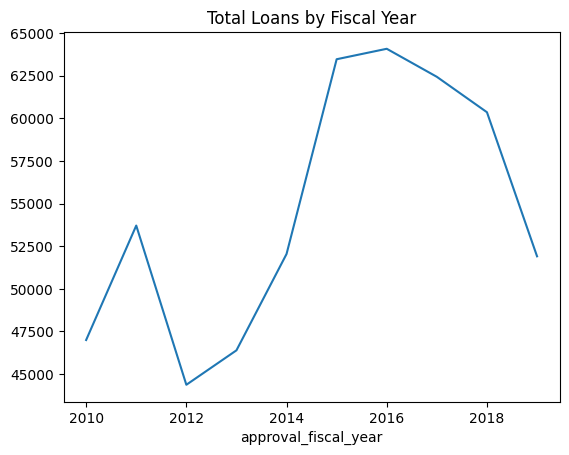

approval_fiscal_year
2010    47000
2011    53710
2012    44376
2013    46395
2014    52044
2015    63461
2016    64074
2017    62430
2018    60354
2019    51907
Name: count, dtype: int64

In [31]:
fy = df['approval_fiscal_year'].value_counts().sort_index()

fy.plot(kind='line', x='approval_fiscal_year')
plt.title('Total Loans by Fiscal Year')
plt.show()
fy

In [32]:
cat_list = ['loan_status', 'borr_state', 'bank_name', 'sba_district_office', 'revolver_status', 'processing_method',
            'subprogram', 'fixed_or_variable_interest', 'business_type', 'business_age', 'collateral_ind', 
            'sold_secondary_mrkt']

for col in cat_list:
    print(df[col].value_counts())
    print()

loan_status
PIF       389005
CANCLD     66399
EXEMPT     56869
CHGOFF     33418
COMMIT        60
Name: count, dtype: int64

borr_state
CA    68070
TX    41841
NY    35267
OH    30880
FL    26345
MI    21267
MA    19616
IL    17994
PA    17552
MN    15408
NJ    15248
GA    14915
WI    14541
WA    14523
CO    13396
IN    12011
AZ    11079
UT    10922
NC    10763
MO     9964
VA     8369
OR     7860
MD     7802
CT     6146
ID     5222
NH     5050
KY     4984
TN     4880
OK     4799
MS     4718
PR     4659
KS     4348
IA     4342
LA     4332
SC     4166
NV     4156
AL     3867
NE     3777
RI     3345
ME     3319
HI     3082
AR     3051
MT     2984
NM     2596
VT     2327
ND     1870
WV     1489
DE     1473
SD     1388
AK     1190
WY     1081
DC      903
GU      449
VI      104
MP       16
FM        3
MH        1
AS        1
Name: count, dtype: int64

bank_name
Wells Fargo Bank National Association        44763
The Huntington National Bank                 37302
JPMorgan Chase Bank, National 

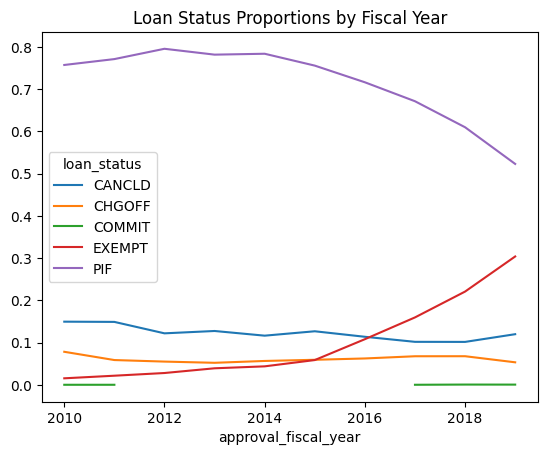

loan_status,CANCLD,CHGOFF,COMMIT,EXEMPT,PIF
approval_fiscal_year,,,,,
2010,14.94%,7.81%,0.00%,1.53%,75.71%
2011,14.89%,5.86%,0.00%,2.15%,77.10%
2012,12.18%,5.49%,nan%,2.79%,79.54%
2013,12.74%,5.21%,nan%,3.91%,78.15%
2014,11.63%,5.64%,nan%,4.37%,78.36%
2015,12.67%,5.92%,nan%,5.85%,75.56%
2016,11.36%,6.23%,nan%,10.79%,71.61%
2017,10.17%,6.75%,0.00%,15.95%,67.12%
2018,10.15%,6.76%,0.05%,22.07%,60.97%


In [46]:
status_by_year = df.groupby('approval_fiscal_year')['loan_status'].value_counts(normalize=True).unstack().reset_index()
status_by_year.plot(kind='line', x='approval_fiscal_year', y=['CANCLD', 'CHGOFF', 'COMMIT', 'EXEMPT', 'PIF'], sharey=True)
plt.title('Loan Status Proportions by Fiscal Year')
plt.show()

loan_status_proportions = status_by_year.set_index('approval_fiscal_year')[['CANCLD', 'CHGOFF', 'COMMIT', 'EXEMPT', 'PIF']]
loan_status_proportions.style.format({'CANCLD': '{:.2%}', 'CHGOFF': '{:.2%}', 'COMMIT': '{:.2%}', 'EXEMPT': '{:.2%}', 'PIF': '{:.2%}'})

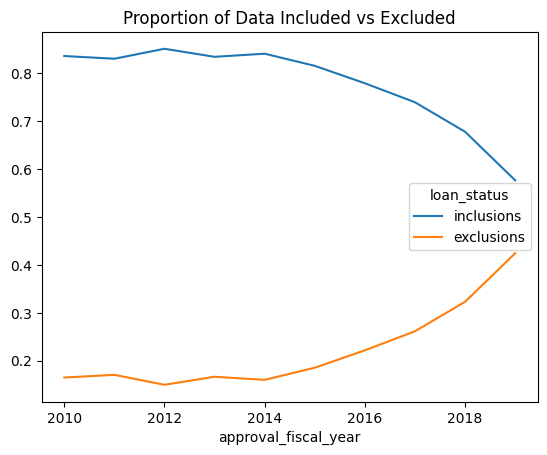

loan_status,inclusions,exclusions
approval_fiscal_year,,
2010,83.52%,16.48%
2011,82.96%,17.04%
2012,85.03%,14.97%
2013,83.36%,16.64%
2014,84.01%,15.99%
2015,81.48%,18.52%
2016,77.84%,22.16%
2017,73.88%,26.12%
2018,67.73%,32.27%


In [34]:
status_by_year['COMMIT'] = status_by_year['COMMIT'].fillna(0)
status_by_year['exclusions'] = status_by_year['CANCLD'] + status_by_year['COMMIT'] + status_by_year['EXEMPT']
status_by_year['inclusions'] = status_by_year['PIF'] + status_by_year['CHGOFF']
status_by_year.plot(kind='line', x='approval_fiscal_year', y=['inclusions', 'exclusions'], sharey=True)
plt.title('Proportion of Data Included vs Excluded')
plt.show()

pct_table = status_by_year.set_index('approval_fiscal_year')[['inclusions', 'exclusions']]
pct_table.style.format({'inclusions': '{:.2%}', 'exclusions': '{:.2%}'})

**Two-digit sector descriptions sourced from Census Bureau NAICS 2022. Two-digit descriptions remain stable across NAICS revisions. https://www.census.gov/naics/?58967?yearbck=2022**

In [35]:
df['naics_code'].str.len().value_counts(dropna=False)

naics_code
6.00    545749
NaN          2
Name: count, dtype: int64

In [36]:
two_digit_desc = {
    '11': 'Agriculture, Forestry, Fishing and Hunting',
    '21': 'Mining, Quarrying, and Oil and Gas Extraction',
    '22': 'Utilities',
    '23': 'Construction',
    '31': 'Manufacturing',
    '32': 'Manufacturing',
    '33': 'Manufacturing',
    '42': 'Wholesale Trade',
    '44': 'Retail Trade',
    '45': 'Retail Trade',
    '48': 'Transportation and Warehousing',
    '49': 'Transportation and Warehousing',
    '51': 'Information',
    '52': 'Finance and Insurance',
    '53': 'Real Estate and Rental and Leasing',
    '54': 'Professional, Scientific, and Technical Services',
    '55': 'Management of Companies and Enterprises',
    '56': 'Administrative and Support and Waste Management and Remediation Services',
    '61': 'Educational Services',
    '62': 'Health Care and Social Assistance',
    '71': 'Arts, Entertainment, and Recreation',
    '72': 'Accommodation and Food Services',
    '81': 'Other Services (except Public Administration)',
    '92': 'Public Administration'
}

two_digit_naics = df['naics_code'].str[:2].to_frame()
two_digit_naics['two_digit_desc'] = two_digit_naics['naics_code'].map(two_digit_desc)
two_digit_naics.value_counts()

naics_code  two_digit_desc                                                          
72          Accommodation and Food Services                                             71306
23          Construction                                                                56907
44          Retail Trade                                                                55004
54          Professional, Scientific, and Technical Services                            54033
62          Health Care and Social Assistance                                           51602
81          Other Services (except Public Administration)                               48947
42          Wholesale Trade                                                             28633
48          Transportation and Warehousing                                              26642
56          Administrative and Support and Waste Management and Remediation Services    24943
33          Manufacturing                                            

### Section Findings
- Loan EXEMPT rates naturally increase as fiscal years approach the present year. Over 30% of data is EXEMPT/CANCLD/COMMIT for FY2018 and FY2019.
- 6.1% of all loans report charge-offs. Excluding EXEMPT, CANCLD, and COMMIT increases that value to 7.9%.
- Construction and Retail are two of the highest reported sectors, providing ample data to test my priors on.
- Fields to be used for analysis and modeling display consistent formatting in value_counts output, not requiring case and/or whitespace cleaning.

## Numeric Data Summary Stats

In [37]:
quant_df = df.loc[:, (df.dtypes == np.int64) & (df.columns != 'loan_id') | (df.dtypes == np.float64)]
quant_df.describe()

,gross_approval,sba_guaranteed_approval,approval_fiscal_year,initial_interest_rate,term_in_months,gross_charge_off_amount,jobs_supported
count,"545,751.00","545,751.00","545,751.00","545,751.00","545,751.00","545,751.00","545,749.00"
mean,"377,395.86","280,086.95","2,014.72",6.53,121.33,"9,389.88",10.72
std,"672,285.50","516,874.70",2.81,1.56,79.76,"81,232.00",20.53
min,"1,000.00",500.00,"2,010.00",0.00,0.00,0.00,0.00
25%,"40,000.00","22,500.00","2,012.00",5.50,84.00,0.00,2.00
50%,"125,000.00","85,000.00","2,015.00",6.00,84.00,0.00,4.00
75%,"360,000.00","273,750.00","2,017.00",7.48,120.00,0.00,11.00
max,"5,000,000.00","4,500,000.00","2,019.00",13.50,847.00,"4,706,180.93","2,150.00"


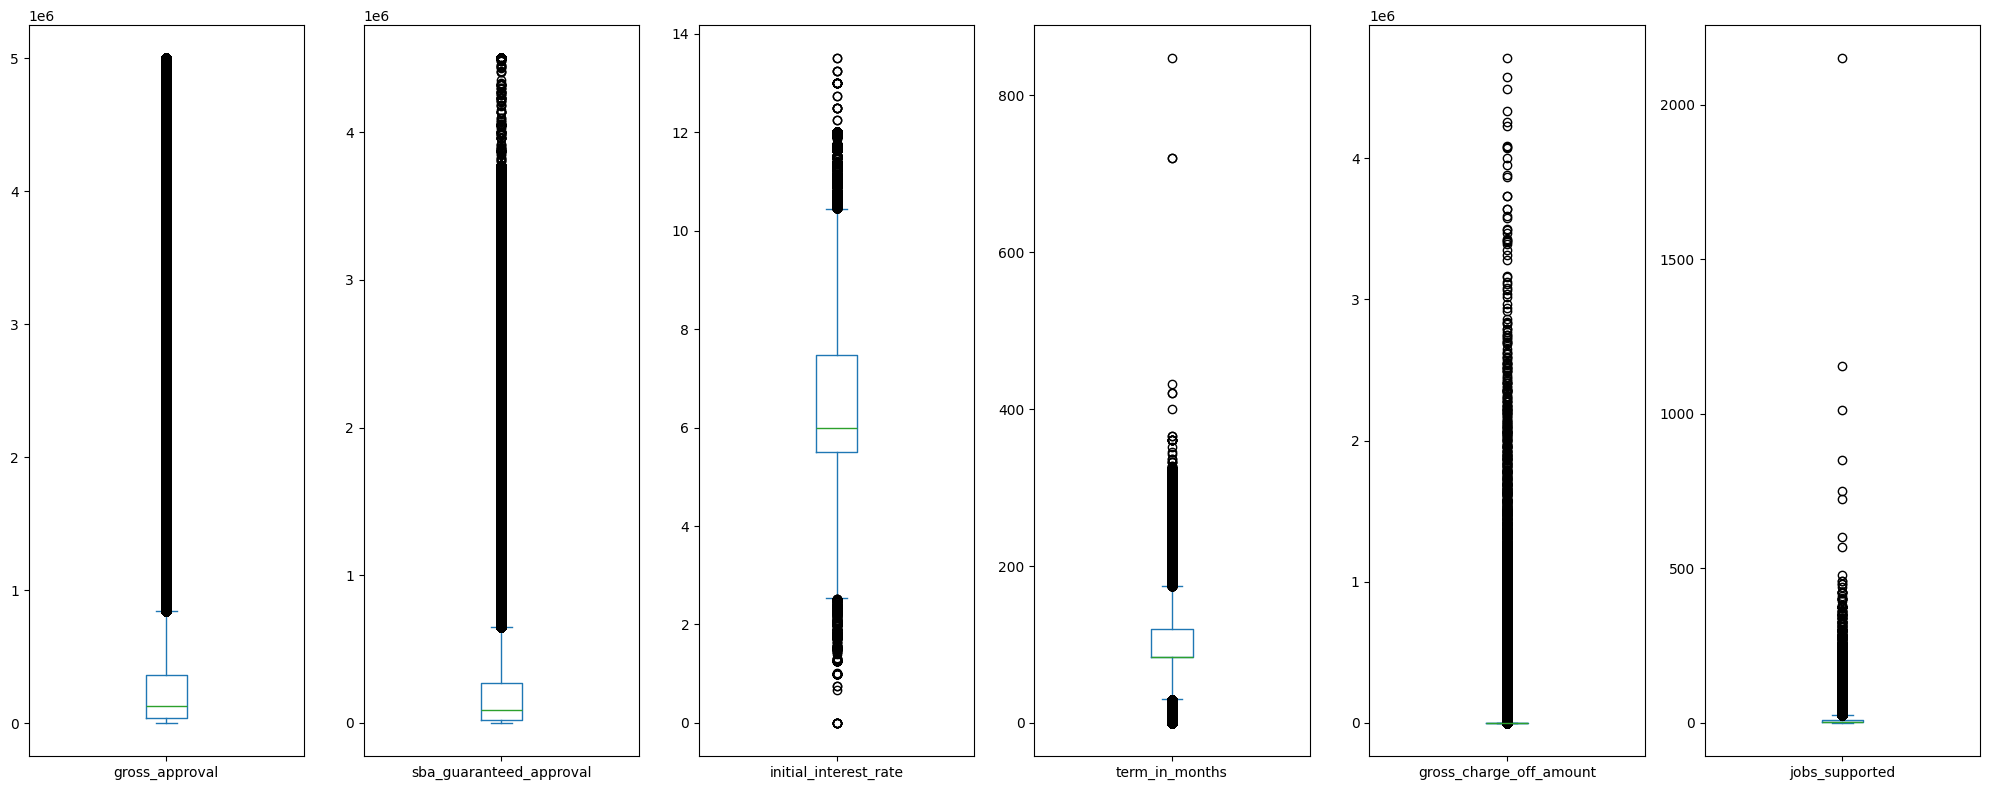

In [38]:
quant_list = quant_df.columns.to_list()
quant_list.remove('approval_fiscal_year')

df[quant_list].plot(kind='box', subplots=True, layout=(1, 6), figsize=(20, 8), sharey=False)
plt.tight_layout()
plt.show()

In [39]:
for col in quant_df:
    print(df[col].value_counts())
    print('\n')

gross_approval
50,000.00       36933
25,000.00       33333
100,000.00      27271
150,000.00      25976
10,000.00       20222
                ...  
3,564,000.00        1
3,040,800.00        1
3,718,500.00        1
1,230,700.00        1
1,986,500.00        1
Name: count, Length: 20014, dtype: int64


sba_guaranteed_approval
25,000.00       32624
12,500.00       30154
50,000.00       20717
5,000.00        18775
127,500.00      15411
                ...  
2,280,600.00        1
2,788,875.00        1
923,025.00          1
187,000.00          1
1,489,875.00        1
Name: count, Length: 26978, dtype: int64


approval_fiscal_year
2016    64074
2015    63461
2017    62430
2018    60354
2011    53710
2014    52044
2019    51907
2010    47000
2013    46395
2012    44376
Name: count, dtype: int64


initial_interest_rate
6.00    82975
5.50    36251
5.25    32537
5.75    29331
6.25    26693
        ...  
6.75        1
4.43        1
4.54        1
7.68        1
7.75        1
Name: count, Length: 1799,

In [40]:
jobs = quant_df['jobs_supported'].dropna()
np.quantile(jobs, 0.99)


np.float64(100.0)

### Section Findings
- Nonsensical outliers reported in term_in_months and jobs_supported, such as loan terms over 300 months (the maximum for 7(a) loans) and one borrower having 2,000 jobs supported.
- Majority of approvals are on the low end: most less than $1MM and many below $100K.
- No anomalies found in gross_approval, sba_guaranteed_approval, approval_fiscal_year, initial_interest_rate, or gross_charge_off_amount.

## Date Logic and Ranges

In [41]:
date_cols = df.select_dtypes('datetime')
date_cols.describe()

,approval_date,first_disbursement_date,paid_in_full_date,charge_off_date
count,545751,478777,389005,33409
mean,2014-12-27 06:47:42,2015-03-10 21:39:05,2019-09-04 05:29:23,2019-10-15 18:00:34
min,2009-10-01 00:00:00,2009-10-01 00:00:00,2009-11-01 00:00:00,2010-06-15 00:00:00
25%,2012-07-25 00:00:00,2012-10-11 00:00:00,2017-03-31 00:00:00,2017-05-05 00:00:00
50%,2015-04-09 00:00:00,2015-06-08 00:00:00,2019-10-31 00:00:00,2019-12-02 00:00:00
75%,2017-05-23 00:00:00,2017-08-31 00:00:00,2022-03-31 00:00:00,2022-07-05 00:00:00
max,2019-09-30 00:00:00,2025-11-15 00:00:00,2025-11-30 00:00:00,2025-12-31 00:00:00


In [42]:
date_ranges = np.round(((date_cols.agg('max') - date_cols.agg('min')).dt.days / 365.25), 2)
date_col_list = date_cols.columns.to_list()

print('Ranges:')
for col_name, years in date_ranges.items():
    print(f'{col_name}: {years} years')

Ranges:
approval_date: 10.0 years
first_disbursement_date: 16.12 years
paid_in_full_date: 16.08 years
charge_off_date: 15.55 years


In [43]:
chgoffs = df[df['loan_status'] == 'CHGOFF']['paid_in_full_date'].unique()
print(chgoffs)


<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[s]


In [44]:
pif = df[df['loan_status'] == 'PIF']['charge_off_date'].unique()
print(pif)


<DatetimeArray>
['NaT']
Length: 1, dtype: datetime64[s]


### Section Findings
- No anomalies found. Percentiles and ranges look agreeable.
- Confirmed PIF loans have no charge_off_date and CHGOFF loans have no paid_in_full_date.

## Cleaning Decisions Summary
- Remove FY2018 and FY2019 from scope due to high percentage of EXEMPT statuses. A significant amount of loans in these vintages have not had enough time to mature, limiting visibility into the data.
- All loans with terms_in_months over the max limit, 300 months (25 years), will be removed.
- Loans with reported jobs_supported exceeding 100, the 99th percentile, will be removed.
- Rows without NAICS will be removed (2 total loans).
- For the ML model only: All loans with statuses of EXEMPT, COMMIT, and CANCLD will be removed.
- Categorical fields used for analysis and modeling display consistent formatting in value_counts output, not requiring case and/or whitespace cleaning.